# Structure set: `RS.CPPP.PHANTOM.dcm`

Load the RTSTRUCT with `pydosert` (against the `CPPP/CT` series) and display each ROI
as a contour overlay on the CT.

In [1]:
from pathlib import Path

import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt

from pydosert.data.utils.dicom_utils import load_ct_series, load_structures
from pydosert.utils.plotting import overlay_mask_outline

ct_folder = Path("CPPP/CT")
rtstruct_path = "CPPP/RS.CPPP.PHANTOM.dcm"

# ROI display colours straight from the RTSTRUCT
_rs = pydicom.dcmread(rtstruct_path)
_num_to_name = {r.ROINumber: r.ROIName for r in _rs.StructureSetROISequence}
roi_colors = {
    _num_to_name[c.ReferencedROINumber]: tuple(v / 255 for v in c.ROIDisplayColor)
    for c in _rs.ROIContourSequence
}
print("ROIs in structure set:", roi_colors)


ROIs in structure set: {'BODY': (0.0, 1.0, 0.0), 'Center': (1.0, 0.0, 1.0)}


In [2]:
# Load the CT series (reference grid) and rasterise every ROI onto it.
# NB: pydosert's load_structures needs explicit names (struct_names=None is broken upstream).
ct_image, _ = load_ct_series(ct_folder)
structures = load_structures(ct_image, ct_folder, rtstruct_path, struct_names=list(roi_colors))

ct = sitk.GetArrayFromImage(ct_image)  # (z, y, x) HU
masks = {name: sitk.GetArrayFromImage(img) > 0 for name, img in structures.items()}

print("CT volume (z, y, x):", ct.shape)
for name, m in masks.items():
    zs = np.where(m.any(axis=(1, 2)))[0]
    print(f"  {name:8s}  voxels={m.sum():>8d}  slices {zs.min()}-{zs.max()}")


CT volume (z, y, x): (83, 512, 512)
  BODY      voxels= 9470400  slices 1-81
  Center    voxels=   43349  slices 33-49


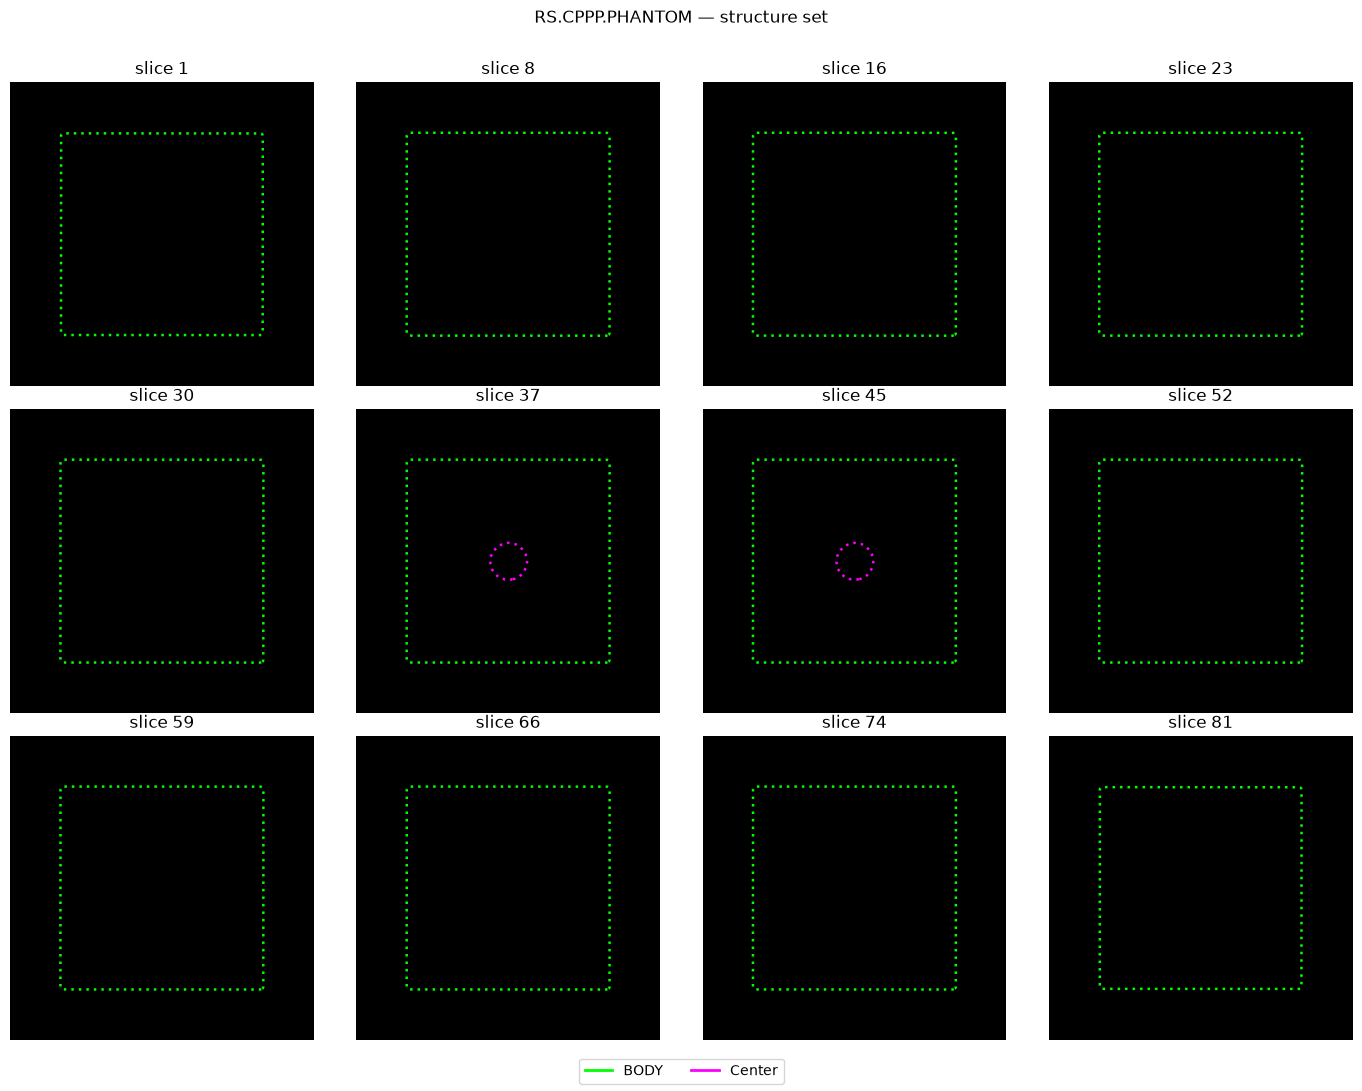

In [3]:
# Axial montage: contour overlays across the slices the structure set covers
union = np.zeros(ct.shape, bool)
for m in masks.values():
    union |= m
zs = np.where(union.any(axis=(1, 2)))[0]
slices = np.linspace(zs.min(), zs.max(), 12).round().astype(int)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, z in zip(axes.ravel(), slices):
    ax.imshow(ct[z], cmap="gray", vmin=-200, vmax=300)
    plt.sca(ax)
    for name, m in masks.items():
        if m[z].any():
            overlay_mask_outline(m[z], color=roi_colors.get(name, "red"), linewidth=1.8)
    ax.set_title(f"slice {z}")
    ax.axis("off")

handles = [plt.Line2D([], [], color=roi_colors.get(n, "red"), lw=2, label=n) for n in masks]
fig.legend(handles=handles, loc="lower center", ncol=len(masks))
fig.suptitle("RS.CPPP.PHANTOM — structure set")
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


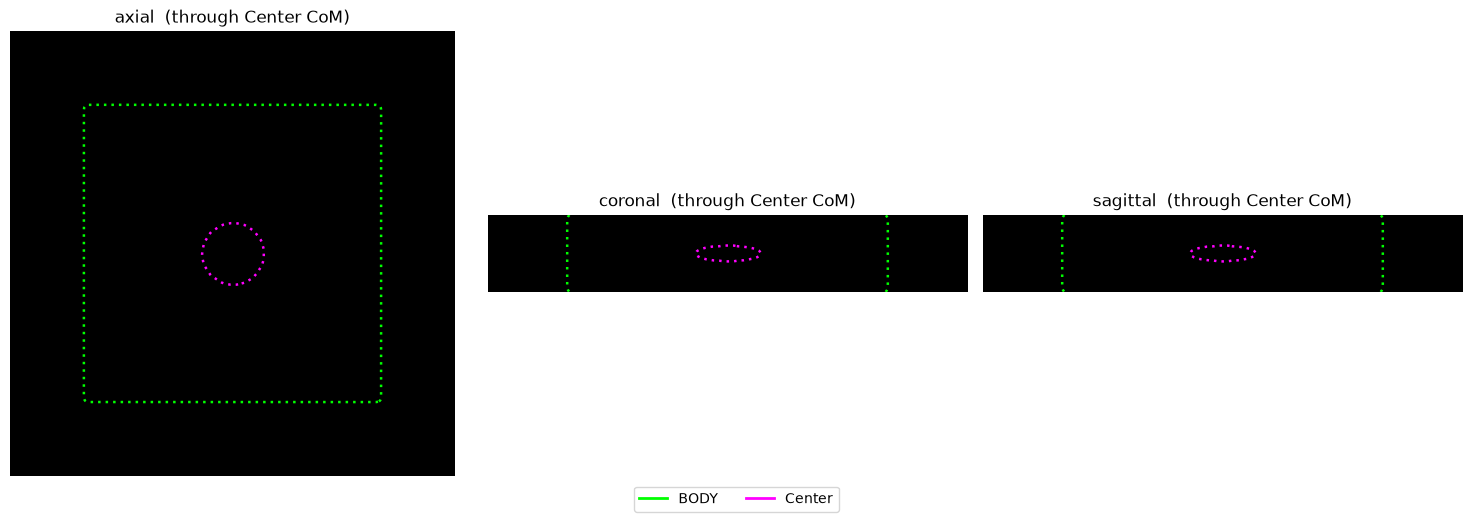

In [4]:
# Orthogonal views through the centre of mass of the smallest ROI
from scipy import ndimage

target = min(masks, key=lambda n: masks[n].sum())
cz, cy, cx = np.array(ndimage.center_of_mass(masks[target])).round().astype(int)

planes = [
    ("axial",    ct[cz, :, :],  lambda m: m[cz, :, :]),
    ("coronal",  ct[:, cy, :],  lambda m: m[:, cy, :]),
    ("sagittal", ct[:, :, cx],  lambda m: m[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, bg, slc) in zip(axes, planes):
    ax.imshow(bg, cmap="gray", vmin=-200, vmax=300, origin="lower" if title != "axial" else "upper")
    plt.sca(ax)
    for name, m in masks.items():
        sl = slc(m)
        if sl.any():
            overlay_mask_outline(sl, color=roi_colors.get(name, "red"), linewidth=1.8)
    ax.set_title(f"{title}  (through {target} CoM)")
    ax.axis("off")
fig.legend(handles=handles, loc="lower center", ncol=len(masks))
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


---
## Dose from a 6 MV (6X) beam

`RP.CPPP.Static.dcm` is a single **static 6 MV AP field** (gantry 0, 10 x 10 cm,
240.8 MU, 25 fx). We compute its dose with `pydosert`'s pencil-beam `DoseEngine`
and show the distribution + DVH for `BODY` and `Center`.

**Note on the CT:** the CT pixel data in this dataset is a placeholder (every voxel
is air / -1000 HU), so the density grid is overridden — `BODY` = water, everything
else = air. The machine model is `pydosert`'s `varian_10MV` preset retuned to a
6 MV beam quality (`TPR20/10 = 0.668`); penumbra / head-scatter parameters are the
stock 10 MV values, so treat the result as illustrative rather than commissioned.

In [5]:
import math

import torch

import pydosert.data.loaders as _ld
from pydosert.data.beam import Beam
from pydosert.data.loaders import load_dicom
from pydosert.data import MachineConfig
from pydosert import DoseEngine

torch.set_grad_enabled(False)
DEVICE = torch.device("cpu")
DTYPE = torch.float32
NLP = 60  # MLC leaf pairs (must match the machine config)

rtplan_path = "CPPP/RP.CPPP.Static.dcm"
rtdose_path = "CPPP/RD.CPPP.Static.dcm"


def fetch_plan_data_static(plan_path, number_of_leaf_pairs=NLP):
    """Drop-in for pydosert.fetch_plan_data that also handles jaw-only STATIC
    fields (RP.CPPP.Static.dcm has no MLCX sequence, which the stock parser skips)."""
    ds = pydicom.dcmread(str(plan_path))
    fg = ds.FractionGroupSequence[0]
    n_frac = int(fg.NumberOfFractionsPlanned)
    metersets = {str(rb.ReferencedBeamNumber): float(rb.BeamMeterset)
                 for rb in fg.ReferencedBeamSequence if hasattr(rb, "BeamMeterset")}

    params = {}
    for beam in ds.BeamSequence:
        mu_tot = metersets.get(str(beam.BeamNumber))
        if mu_tot is None:
            continue
        n_cp = len(beam.ControlPointSequence)
        sid = float(beam.SourceAxisDistance)
        gantry = coll = ssd = 0.0
        iso = None
        jaw_x = np.array([-100.0, 100.0])
        jaw_y = np.array([-100.0, 100.0])
        old_mu, beams = 0.0, []
        for cp in beam.ControlPointSequence:
            if cp.get("GantryAngle") is not None:              gantry = float(cp.GantryAngle)
            if cp.get("BeamLimitingDeviceAngle") is not None:  coll = float(cp.BeamLimitingDeviceAngle)
            if cp.get("SourceToSurfaceDistance") is not None:  ssd = float(cp.SourceToSurfaceDistance)
            if cp.get("IsocenterPosition") is not None and iso is None:
                ip = cp.IsocenterPosition
                iso = (float(ip[2]), float(ip[1]), float(ip[0]))
            for s in cp.get("BeamLimitingDevicePositionSequence", []):
                p = [float(v) for v in s.LeafJawPositions]
                if s.RTBeamLimitingDeviceType in ("ASYMX", "X"):   jaw_x = np.array([p[0], p[1]])
                elif s.RTBeamLimitingDeviceType in ("ASYMY", "Y"): jaw_y = np.array([p[0], p[1]])

            mu_val = mu_tot if n_cp == 2 else mu_tot * float(cp.CumulativeMetersetWeight)
            leaves = np.zeros((number_of_leaf_pairs, 2))
            leaves[:, 0], leaves[:, 1] = jaw_x[0], jaw_x[1]
            beams.append(Beam(
                gantry_angle=math.radians(gantry),
                collimator_angle=math.radians(coll),
                ssd=ssd,
                mu=torch.from_numpy(np.array(mu_val - old_mu)),
                leaf_positions=torch.from_numpy(leaves),
                jaw_positions=torch.from_numpy(jaw_y.astype(np.float64)),
                field_size=(400, 400),
                sid=sid,
                iso_center=iso,
            ))
            old_mu = mu_val
        if beams:
            params[f"{ds.SOPInstanceUID}_{beam.BeamNumber}"] = (beams, n_frac)
    return params


_ld.fetch_plan_data = fetch_plan_data_static


In [6]:
# Load CT + structures + plan + reference dose onto pydosert's 2 mm dose grid
patient, beam_sequences = load_dicom(
    ct_folder,
    dose_path=[rtdose_path],
    plan_path=[rtplan_path],
    struct_path=rtstruct_path,
    struct_names=list(roi_colors),
    device="cpu",
    dtype=DTYPE,
    crop_volume=True,
)
patient = patient.to("cpu").to(DTYPE)
beam_sequence = beam_sequences[0].to("cpu")

dose_masks = patient.structures                 # {name: bool tensor [D, H, W]} on the dose grid
n_fx = patient.number_of_fractions
res = tuple(patient.resolution)

# CT is a placeholder (all air) -> override density: BODY = water, else air
density = torch.where(dose_masks["BODY"], 1.0, 0.0012).to(DTYPE)

print("dose grid (D, H, W):", tuple(density.shape), " voxel (mm):", res, " fractions:", n_fx)
print("beam gantry (deg):", beam_sequence.gantry_angles_deg,
      " MU:", [round(m, 1) for m in beam_sequence.mus.tolist()])


dose grid (D, H, W): (104, 150, 150)  voxel (mm): (2.0, 2.0, 2.0)  fractions: 25
beam gantry (deg): [0. 0.]  MU: [240.8, 0.0]


In [7]:
# 6 MV machine model + pencil-beam dose engine (auto-calibrated: calibration MU -> 1 Gy at 10 cm in water)
machine = MachineConfig(
    preset="varian_10MV",
    tpr_20_10=0.668,          # 6 MV beam quality
    mean_photon_energy_MeV=2.0,
    leaf_widths=None,
    number_of_leaf_pairs=NLP,
)

engine = DoseEngine(
    machine_config=machine,
    kernel_size=31,
    dose_grid_spacing=res,
    dose_grid_shape=tuple(density.shape),
    device=DEVICE,
    dtype=DTYPE,
    auto_calibrate=True,
)

dose_fx = engine.compute_dose(beam_sequence, density_image=density).squeeze(0)  # Gy / fraction
dose_plan = dose_fx * n_fx                                                      # Gy, full course
ref_plan = patient.dose * n_fx                                                  # TPS reference, full course

print(f"pydosert  Dmax = {float(dose_plan.max()):.1f} Gy   (per fraction {float(dose_fx.max()):.2f} Gy)")
print(f"TPS ref   Dmax = {float(ref_plan.max()):.1f} Gy")


C:\Users\mross\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydosert\engine\dose_engine.py:265: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.amp.autocast(self.device.type, dtype=self.dtype):


pydosert  Dmax = 90.6 Gy   (per fraction 3.62 Gy)
TPS ref   Dmax = 77.8 Gy


### Summary statistics for the two structures

For each ROI we tabulate, for both dose cubes:

* **first-order stats** on the in-ROI voxel doses — min / max / mean / SD / median;
* **DVH points** — D98%, D95%, D50%, D2% (near-min → near-max), and D2cc;
* for the target (`Center`, Rx = 2 Gy × 25 = 50 Gy) also the **homogeneity index**
  `HI = (D2% − D98%) / D50%` and coverage `V95/100/107 %Rx`.

Then the pydosert − TPS difference per metric, and a voxel-wise dose-difference
summary inside each ROI.

In [8]:
# --- Summary DVH statistics --------------------------------------------------
# pydosert ships DVH primitives in pydosert.objectives.metrics; wrap them.
from pydosert.objectives.metrics import (
    dose_at_volume_percent,   # Dx%  : dose covering x% of the volume
    dose_at_volume_cc,        # Dxcc : dose to the hottest x cm^3
    volume_at_dose,           # VxGy : % volume receiving >= x Gy
)

voxel_cc = float(np.prod(res)) / 1000.0          # (2 mm)^3 -> 0.008 cc


def dvh_statistics(dose3d, mask, rx_gy=None, voxel_cc=voxel_cc):
    """Summary statistics of one dose cube (Gy) over one boolean structure mask.

    dose3d, mask : numpy arrays [D, H, W]. Returns an ordered dict of metrics.
    """
    dose3d = np.asarray(dose3d, dtype=float)
    mask = np.asarray(mask) > 0
    d = dose3d[mask]
    s = {
        "n_vox":     float(d.size),
        "volume_cc": d.size * voxel_cc,
        "Dmin":      float(d.min()),
        "Dmax":      float(d.max()),
        "Dmean":     float(d.mean()),
        "Dstd":      float(d.std()),
        "Dmedian":   float(np.median(d)),
        "D98%":      dose_at_volume_percent(dose3d, mask, 98.0),   # near-minimum
        "D95%":      dose_at_volume_percent(dose3d, mask, 95.0),
        "D50%":      dose_at_volume_percent(dose3d, mask, 50.0),
        "D2%":       dose_at_volume_percent(dose3d, mask, 2.0),    # near-maximum
        "D2cc":      dose_at_volume_cc(dose3d, mask, 2.0, voxel_cc),
    }
    if rx_gy:
        s["HI"]        = (s["D2%"] - s["D98%"]) / s["D50%"]        # ICRU-83 homogeneity index
        s["V95%Rx_%"]  = volume_at_dose(dose3d, mask, 0.95 * rx_gy)
        s["V100%Rx_%"] = volume_at_dose(dose3d, mask, 1.00 * rx_gy)
        s["V107%Rx_%"] = volume_at_dose(dose3d, mask, 1.07 * rx_gy)
    return s


In [9]:
# Per-structure comparison table: pydosert vs TPS reference (full course, Gy)
dp = dose_plan.cpu().numpy()
rp = ref_plan.cpu().numpy()
rx_gy = {"Center": 2.0 * n_fx, "BODY": None}     # Center prescription = 2 Gy / fraction

stats = {}   # keep for later use
for name, m in dose_masks.items():
    mk = m.cpu().numpy()
    pd_s = dvh_statistics(dp, mk, rx_gy.get(name))
    tps_s = dvh_statistics(rp, mk, rx_gy.get(name))
    stats[name] = {"pydosert": pd_s, "TPS": tps_s}

    hdr = f"Rx = {rx_gy[name]:g} Gy" if rx_gy.get(name) else "(no prescription)"
    print(f"\n=== {name}   {hdr} " + "=" * (40 - len(name) - len(hdr)))
    print(f"{'metric':11s} {'pydosert':>12s} {'TPS':>12s} {'Δ (pd−TPS)':>12s} {'Δ %':>8s}")
    for k in pd_s:
        a, b = pd_s[k], tps_s[k]
        if k == "n_vox":
            print(f"{k:11s} {a:12.0f} {b:12.0f}")
            continue
        d = a - b
        pct = 100.0 * d / b if b else float("nan")
        print(f"{k:11s} {a:12.3f} {b:12.3f} {d:+12.3f} {pct:+8.1f}")



=== BODY   (no prescription) ===================
metric          pydosert          TPS   Δ (pd−TPS)      Δ %
n_vox            1009503      1009503
volume_cc       8076.024     8076.024       +0.000     +0.0
Dmin               0.001        0.096       -0.095    -98.7
Dmax              90.559       77.840      +12.719    +16.3
Dmean             14.380       13.540       +0.839     +6.2
Dstd              24.068       20.593       +3.474    +16.9
Dmedian            1.260        2.485       -1.225    -49.3
D98%               0.012        0.548       -0.536    -97.8
D95%               0.027        0.742       -0.715    -96.3
D50%               1.260        2.485       -1.225    -49.3
D2%               83.301       72.344      +10.957    +15.1
D2cc              90.442       77.684      +12.758    +16.4

=== Center   Rx = 50 Gy ========================
metric          pydosert          TPS   Δ (pd−TPS)      Δ %
n_vox               4688         4688
volume_cc         37.504       37.504       

In [10]:
# Voxel-wise dose difference (pydosert - TPS) inside each structure
print(f"{'ROI':8s} {'mean Δ':>10s} {'mean |Δ|':>10s} {'max |Δ|':>10s} {'95th |Δ|':>10s}   (Gy)")
for name, m in dose_masks.items():
    diff = (dp - rp)[m.cpu().numpy()]
    print(f"{name:8s} {diff.mean():+10.2f} {np.abs(diff).mean():10.2f} "
          f"{np.abs(diff).max():10.2f} {np.percentile(np.abs(diff), 95):10.2f}")


ROI          mean Δ   mean |Δ|    max |Δ|   95th |Δ|   (Gy)
BODY          +0.84       2.47      22.75       9.38
Center        +4.97       4.97       5.95       5.78


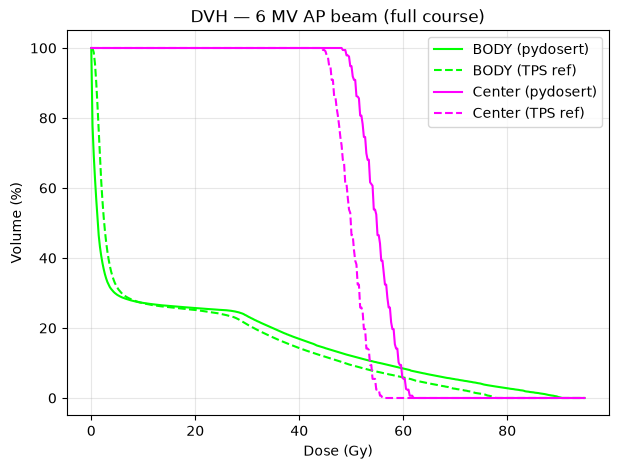

In [11]:
# Dose-volume histogram for BODY and Center (pydosert vs TPS reference)
plt.figure(figsize=(7, 5))
dmax = float(max(dose_plan.max(), ref_plan.max())) * 1.05
bins = np.linspace(0, dmax, 400)
for name, m in dose_masks.items():
    col = roi_colors[name]
    for arr, ls, tag in ((dose_plan, "-", "pydosert"), (ref_plan, "--", "TPS ref")):
        vals = arr[m].cpu().numpy()
        h, edges = np.histogram(vals, bins=bins)
        cum = np.cumsum(h[::-1])[::-1] / max(h.sum(), 1)
        plt.plot(edges[:-1], cum * 100, ls, color=col, label=f"{name} ({tag})")
plt.xlabel("Dose (Gy)")
plt.ylabel("Volume (%)")
plt.title("DVH — 6 MV AP beam (full course)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


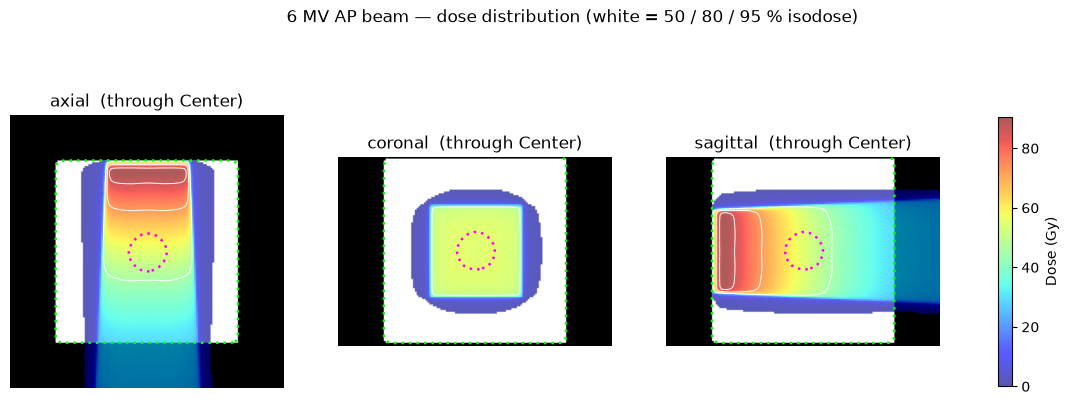

In [12]:
# Dose wash on the three orthogonal planes through Center, with ROI outlines + isodose lines
cz, cy, cx = np.array(
    ndimage.center_of_mass(dose_masks["Center"].cpu().numpy())
).round().astype(int)

dn = dose_plan.cpu().numpy()
bgn = density.cpu().numpy()
vmax = float(dn.max())

views = [
    ("axial",    bgn[cz],       dn[cz],       lambda a: a[cz]),
    ("coronal",  bgn[:, cy],    dn[:, cy],    lambda a: a[:, cy]),
    ("sagittal", bgn[:, :, cx], dn[:, :, cx], lambda a: a[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, bg, dd, slc) in zip(axes, views):
    ax.imshow(bg, cmap="gray")
    im = ax.imshow(np.ma.masked_less(dd, 0.02 * vmax), cmap="jet", vmin=0, vmax=vmax, alpha=0.65)
    ax.contour(dd, levels=[0.5 * vmax, 0.8 * vmax, 0.95 * vmax], colors="white", linewidths=0.7)
    plt.sca(ax)
    for name, m in dose_masks.items():
        s = slc(m.cpu().numpy())
        if s.any():
            overlay_mask_outline(s, color=roi_colors[name], linewidth=1.8)
    ax.set_title(f"{title}  (through Center)")
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="Dose (Gy)")
fig.suptitle("6 MV AP beam — dose distribution (white = 50 / 80 / 95 % isodose)")
plt.show()
